# 12 &middot; Quadratic (P2) finite elements

So far every element in these tutorials has been **linear (P1)**: positions vary
linearly inside each triangle/tet, so the deformation gradient $F$ is *constant*
per element. **Quadratic (P2)** elements add a node at every edge midpoint and let
positions vary *quadratically*, so $F$ varies *within* an element and bending is
captured far more accurately for the same mesh.

This tutorial covers the three ingredients and one extra piece:

1. `linear_to_quadratic_elements` &mdash; build the midpoint-enriched mesh ($t \times 6$ / $t \times 10$).
2. `gauss_legendre_quadrature` &mdash; symmetric per-element cubature points + weights.
3. `deformation_jacobian_p2` &mdash; the constant operator mapping nodal positions to
   one $F$ **per cubature point**.
4. `p2_massmatrix` / `p2_gravity_force` &mdash; inertia and gravity over the P2 nodes.

### Is the P2 deformation-Jacobian constant?

**Yes** &mdash; exactly like P1 it is a fixed sparse matrix built once from the rest
geometry and the fixed reference quadrature points, independent of the deformed
state. The only difference: P2 shape-function gradients are *linear* in the
reference coordinates, so $F$ is no longer constant inside an element. That is
why the operator maps to a *stack* of per-cubature $F$ blocks.

### How does P2 change energy integration?

With P1 the energy is a one-point rule, $E = \sum_t \text{vol}_t \, \psi(F_t)$. With P2 the
energy becomes a sum over cubature points, $E = \sum_t \sum_q w_{tq} \, \psi(F_{tq})$.
**No energy code changes** &mdash; treat each cubature point as a pseudo-element: stack
$F$ to $(t \cdot n_\text{quad}, \dim, \dim)$ and pass `weights.reshape(-1, 1)` as the `vol`.

In [1]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.collections import PolyCollection
from matplotlib.animation import FuncAnimation
import simkit
import simkit.energies as energies
from simkit.solvers import newton_solver
import utils

## Part A &mdash; Visualizing the basis functions

On a single reference triangle we plot all three **P1** hat functions and all six
**P2** basis functions. The P1 hats are exactly the barycentric coordinates
(planar ramps). The P2 corner functions $N_i = L_i(2 L_i - 1)$ curve and even dip
slightly negative near the opposite edge, while the midpoint functions
$N = 4 L_a L_b$ are bumps centered on their edge. `simkit.p2_shape_functions`
returns these values (and their gradients).

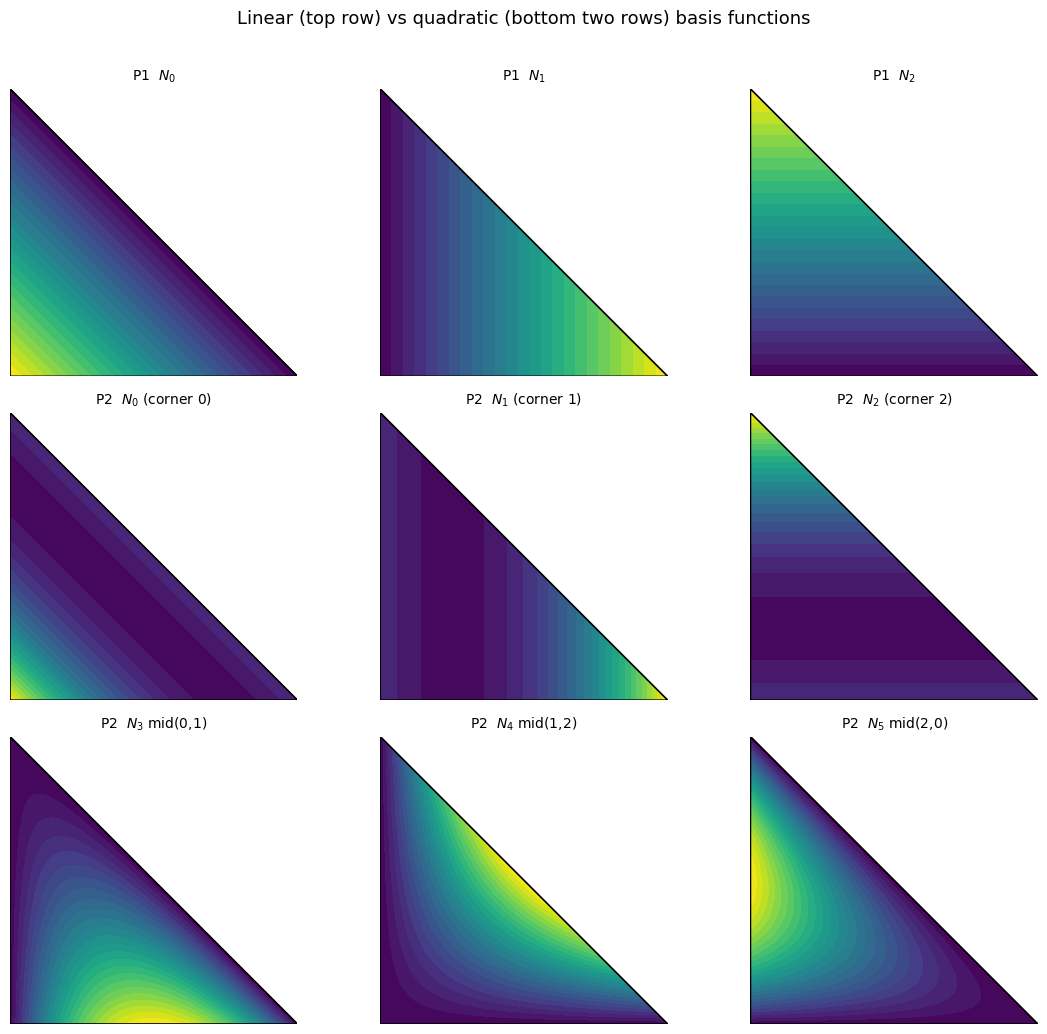

In [2]:
# Sample the reference triangle: barycentric L = (L0, L1, L2), cartesian (x, y) = (L1, L2).
m = 70
samples = []
for x in np.linspace(0.0, 1.0, m):
    for y in np.linspace(0.0, 1.0 - x, max(2, int(m * (1.0 - x)) + 1)):
        samples.append((x, y))
xy = np.array(samples)
L = np.column_stack([1.0 - xy[:, 0] - xy[:, 1], xy[:, 0], xy[:, 1]])
tri = mtri.Triangulation(xy[:, 0], xy[:, 1])

# P1 hats are just the barycentric coordinates; P2 basis from simkit.
P1 = L                                                            # (npts, 3)
P2 = np.array([simkit.p2_shape_functions(Li, 3)[0] for Li in L])  # (npts, 6)

p1_titles = [r"P1  $N_0$", r"P1  $N_1$", r"P1  $N_2$"]
p2_titles = [r"P2  $N_0$ (corner 0)", r"P2  $N_1$ (corner 1)", r"P2  $N_2$ (corner 2)",
             r"P2  $N_3$ mid(0,1)",  r"P2  $N_4$ mid(1,2)",  r"P2  $N_5$ mid(2,0)"]

def draw(ax, vals, title):
    tcf = ax.tricontourf(tri, vals, levels=24, cmap="viridis")
    ax.plot([0, 1, 0, 0], [0, 0, 1, 0], "k", lw=1.2)   # reference-triangle outline
    ax.set_title(title, fontsize=10); ax.set_aspect("equal"); ax.axis("off")
    return tcf

fig, axes = plt.subplots(3, 3, figsize=(11.5, 10.5))
for j in range(3):
    draw(axes[0, j], P1[:, j], p1_titles[j])
for k in range(6):
    draw(axes[1 + k // 3, k % 3], P2[:, k], p2_titles[k])
fig.suptitle("Linear (top row) vs quadratic (bottom two rows) basis functions",
             fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig("media/12_p2_basis.png", dpi=110)
plt.show()

## Part B &mdash; A beam sagging under gravity: P1 vs P2

We drop a cantilever beam (left edge pinned) under gravity with inertia, using a
backward-Euler implicit step (the integrator from tutorial 7). We run the **same**
material and timestep twice: once with linear elements, once with quadratic
elements on the same coarse mesh, and animate them side by side. The energy code
(`macklin_mueller_neo_hookean_*`) is identical in both &mdash; only $J$, the weights,
the mass matrix and gravity differ.

### One simulator, two element sets

`FEMBeam` is a single backward-Euler neo-Hookean beam parametrized purely by its
assembled operators: the deformation Jacobian $J$, the per-cubature weights `vol`,
the Lame parameters, the mass matrix $M$, the gravity force $f_g$, and the pin
penalty $(Q, b)$. Whether those came from the P1 pipeline (`deformation_jacobian`
/ `volume` / `massmatrix` / `gravity_force`) or the P2 pipeline
(`deformation_jacobian_p2` / `gauss_legendre_quadrature` / `p2_massmatrix` /
`p2_gravity_force`) makes no difference to the physics. The `energy / gradient /
hessian` methods build their elastic, pin, gravity and inertia terms **one per
line**, and `step()` drives one implicit step with `utils.Inertia` + `newton_solver`.

In [3]:
class FEMBeam:
    """Backward-Euler neo-Hookean beam; works for P1 or P2 depending on the
    (vertices, J, vol, mass M, gravity f_g, pin penalty) passed in.

    The elastic energy is integrated as sum_blk vol_blk * psi(F_blk): for P1 a
    block is an element, for P2 a block is a per-element cubature point. Nothing
    else in the dynamics is aware of which space it is running in."""

    def __init__(self, nodes, J, vol, mu, lam, M, f_g, Q_pin, b_pin, h):
        self.nodes = nodes
        self.n, self.dim = nodes.shape
        self.J, self.vol = J, vol
        self.mu, self.lam = mu, lam
        self.M, self.f_g = M, f_g
        self.Q_pin, self.b_pin = Q_pin, b_pin
        self.inertia = utils.Inertia(M, h)
        self.h = h

    def energy(self, x):
        xn, xc = x.reshape(-1, self.dim), x.reshape(-1, 1)
        E_elastic = energies.macklin_mueller_neo_hookean_energy_x(xn, self.J, self.mu, self.lam, self.vol)
        E_pin     = 0.5 * (xc.T @ (self.Q_pin @ xc))[0, 0] + (self.b_pin.T @ xc)[0, 0]
        E_gravity = -(self.f_g.T @ xc)[0, 0]
        E_inertia = self.inertia.energy(xc)
        return E_elastic + E_pin + E_gravity + E_inertia

    def gradient(self, x):
        xn, xc = x.reshape(-1, self.dim), x.reshape(-1, 1)
        g_elastic = energies.macklin_mueller_neo_hookean_gradient_x(xn, self.J, self.mu, self.lam, self.vol)
        g_pin     = self.Q_pin @ xc + self.b_pin
        g_gravity = -self.f_g
        g_inertia = self.inertia.gradient(xc)
        return g_elastic + g_pin + g_gravity + g_inertia

    def hessian(self, x):
        xn = x.reshape(-1, self.dim)
        H_elastic = energies.macklin_mueller_neo_hookean_hessian_x(xn, self.J, self.mu, self.lam, self.vol, psd=True)
        H_pin     = self.Q_pin
        H_inertia = self.inertia.hessian(x.reshape(-1, 1))
        return H_elastic + H_pin + H_inertia

    def step(self, U, V):
        self.inertia.update(U.reshape(-1, 1), V.reshape(-1, 1))
        x = newton_solver(U.reshape(-1, 1).copy(), self.energy, self.gradient, self.hessian,
                          max_iter=30, tolerance=1e-8)
        U_next = x.reshape(self.n, self.dim)
        return U_next, (U_next - U) / self.h

### Assembling the two operator sets

P1 reuses the standard `precompute`-style operators. P2 needs its own assembly
(the midpoint-enriched mesh, cubature points/weights, and the per-cubature
deformation Jacobian, mass matrix and gravity), which `utils.precompute` does not
cover &mdash; so we build them with a small precompute helper. The energy term
structure stays out in the simulator class; this helper only *assembles* operators.

In [4]:
# Shared coarse beam (deliberately coarse so the P1-vs-P2 difference is visible).
X, T = utils.triangulated_grid(nx=5, ny=4, width=2.0, height=0.3)
YM, PR, RHO, GRAV = 300.0, 0.4, 1.0, -9.8
H, T_TOTAL, N_FRAMES = 0.01, 1.2, 48
MU_NH, LAM_NH = simkit.ympr_to_lame(YM, PR)

def assemble_p2_operators(X, T, rho, grav, order=2):
    """Build the P2 operator set on the midpoint-enriched mesh: vertices, the
    per-cubature deformation Jacobian + weights, the mass matrix and gravity."""
    V2, T2 = simkit.linear_to_quadratic_elements(X, T)
    bary, w = simkit.gauss_legendre_quadrature(X, T, order)     # cubature for the elastic energy
    J2  = simkit.deformation_jacobian_p2(V2, T2, bary, w)
    vol = w.reshape(-1, 1)                                      # per-cubature physical weights
    M2  = sp.sparse.kron(simkit.p2_massmatrix(V2, T2, bary, w, rho=rho), sp.sparse.eye(X.shape[1])).tocsc()
    fg2 = simkit.p2_gravity_force(V2, T2, bary, w, a=grav, rho=rho).reshape(-1, 1)
    return V2, T2, J2, vol, M2, fg2

# ---- P1 (linear) operators on (X, T) ----
n1, dim = X.shape
J1   = simkit.deformation_jacobian(X, T)
vol1 = simkit.volume(X, T)
M1   = sp.sparse.kron(simkit.massmatrix(X, T, rho=RHO), sp.sparse.eye(dim)).tocsc()
fg1  = simkit.gravity_force(X, T, a=GRAV, rho=RHO).reshape(-1, 1)
pin1 = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
Q1, b1 = simkit.dirichlet_penalty(pin1, X[pin1], n1, 1e7)
mu1  = np.full((vol1.shape[0], 1), MU_NH); lam1 = np.full((vol1.shape[0], 1), LAM_NH)

# ---- P2 (quadratic) operators on the midpoint-enriched mesh ----
V2, T2, J2, vol2, M2, fg2 = assemble_p2_operators(X, T, RHO, GRAV, order=2)
n2 = V2.shape[0]
pin2 = np.where(V2[:, 0] <= V2[:, 0].min() + 1e-6)[0]
Q2, b2 = simkit.dirichlet_penalty(pin2, V2[pin2], n2, 1e7)
mu2  = np.full((vol2.shape[0], 1), MU_NH); lam2 = np.full((vol2.shape[0], 1), LAM_NH)

beam_p1 = FEMBeam(X,  J1, vol1, mu1, lam1, M1, fg1, Q1, b1, H)
beam_p2 = FEMBeam(V2, J2, vol2, mu2, lam2, M2, fg2, Q2, b2, H)

print(f"P1: {n1} nodes, {T.shape[0]} elements, {n1*dim} dofs")
print(f"P2: {n2} nodes, {T2.shape[0]} elements, {n2*dim} dofs")

P1: 20 nodes, 24 elements, 40 dofs
P2: 63 nodes, 24 elements, 126 dofs


### Curved (true-geometry) rendering of P2 elements

A P2 element edge between corners $a, b$ (with shared midpoint node $m$) is a
*parabola* in the edge parameter $t \in [0, 1]$:

$$
x(t) = N_a(t)\, U_a + N_b(t)\, U_b + N_m(t)\, U_m,
$$

$$
N_a = (1-t)(1-2t), \quad N_b = t(2t-1), \quad N_m = 4 t (1-t).
$$

Sampling $t$ densely traces the REAL curved boundary &mdash; something straight-line
subdivision (or any linear P1 element) can never produce.

In [5]:
S = 12
_t = np.linspace(0.0, 1.0, S)
_W = np.column_stack([(1 - _t) * (1 - 2 * _t), _t * (2 * _t - 1), 4 * _t * (1 - _t)])  # (S, 3)
# Boundary edges for our node order [c0,c1,c2, m01,m12,m20]: (corner_a, corner_b, mid).
_EDGES = [(0, 1, 3), (1, 2, 4), (2, 0, 5)]

def p2_curved_loops(U2, T2):
    """One (3*S, 2) curved boundary polygon per P2 element (parabolic edges)."""
    loops = []
    for el in np.asarray(T2):
        pieces = [_W @ U2[[el[a], el[b], el[m]]] for (a, b, m) in _EDGES]
        loops.append(np.vstack(pieces))
    return loops

class CurvedP2Artist:
    """Like utils.PolyMeshArtist, but draws each P2 element's true curved edges."""
    def __init__(self, ax, U2, T2, facecolor=utils.MESH_FACE,
                 edgecolor=utils.MESH_EDGE, lw=1.0, zorder=2, alpha=0.95):
        self.T2 = np.asarray(T2)
        self.coll = PolyCollection(p2_curved_loops(np.asarray(U2, float), self.T2),
                                   facecolors=facecolor, edgecolors=edgecolor,
                                   linewidths=lw, zorder=zorder, alpha=alpha)
        ax.add_collection(self.coll)
    def update(self, U2):
        self.coll.set_verts(p2_curved_loops(np.asarray(U2, float), self.T2))

def animate_p1_p2(states_p1, states_p2, T_p1, T2, *, lims, fps=24, suptitle=None,
                  titles=("Linear (P1) - straight edges",
                          "Quadratic (P2) - true curved edges")):
    """1x2 animation: P1 via PolyMeshArtist (straight) vs P2 via CurvedP2Artist."""
    (xlim, ylim) = lims
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.4))
    utils.setup_axes(axes[0], xlim, ylim, title=titles[0])
    utils.setup_axes(axes[1], xlim, ylim, title=titles[1])
    a1 = utils.PolyMeshArtist(axes[0], states_p1[0], T_p1)
    a2 = CurvedP2Artist(axes[1], states_p2[0], T2)
    if suptitle:
        fig.suptitle(suptitle)
    nframes = max(len(states_p1), len(states_p2))
    def update(i):
        a1.update(states_p1[min(i, len(states_p1) - 1)])
        a2.update(states_p2[min(i, len(states_p2) - 1)])
        return ()
    anim = FuncAnimation(fig, update, frames=nframes, interval=1000 / fps, blit=False)
    fig.tight_layout()
    return fig, anim

### Running both beams

Each beam is stepped with its own explicit backward-Euler loop, sampling
`N_FRAMES` evenly-spaced frames. P1 is drawn with its native straight triangles;
P2 with its TRUE curved geometry (parabolic edges) &mdash; not straight
sub-triangles.

In [6]:
sample = np.linspace(0, T_TOTAL, N_FRAMES)

# ---- P1 backward-Euler rollout ----
U, V = X.copy(), np.zeros_like(X)
t, si, states_p1 = 0.0, 0, [X.copy()]
while si < N_FRAMES - 1:
    U, V = beam_p1.step(U, V); t += H
    while si < N_FRAMES - 1 and t >= sample[si + 1]:
        si += 1; states_p1.append(U.copy())

# ---- P2 backward-Euler rollout ----
U, V = V2.copy(), np.zeros_like(V2)
t, si, states_p2 = 0.0, 0, [V2.copy()]
while si < N_FRAMES - 1:
    U, V = beam_p2.step(U, V); t += H
    while si < N_FRAMES - 1 and t >= sample[si + 1]:
        si += 1; states_p2.append(U.copy())

fig, anim = animate_p1_p2(
    states_p1, states_p2, T, T2,
    lims=((-1.25, 1.45), (-1.6, 0.4)), fps=24,
    suptitle="Same mesh, same material, same dt: only P2's edges can curve")
utils.show_video(fig, anim, "media/12_p1_vs_p2_beam.mp4", fps=24)

### Wait &mdash; is this just a subdivided mesh?

A fair question, because the P2 element and a triangle **subdivided into 4 linear
sub-triangles** use the *exact same 6 nodes* (3 corners + 3 edge midpoints). The
difference is not the nodes, it is the **function space**:

| scheme | nodes | within an element | edges |
|---|---|---|---|
| **P1 linear** | 3 corners | constant $F$ | straight (cannot curve) |
| **Subdivided P1** | same 6 | piecewise-constant $F$, kinks at midpoints | straight chords |
| **P2 quadratic** | same 6 | $F$ varies linearly & smoothly | **curved (parabolic)** |

Below we apply one known quadratic bending field, $\phi(x, y) = (x, y + 0.5 x^2)$,
to a single triangle and render it three ways. The dashed grey curve is the *true*
smooth shape. P1 is flat; subdivision is a kinked, piecewise-straight chord on the
same nodes; **only the quadratic basis curves to match the truth** &mdash; which is also
why the P2 patch test (`test_quadratic_field_gradient_matches_analytic`)
reproduces such fields to ~1e-10 while no linear scheme on these nodes can.

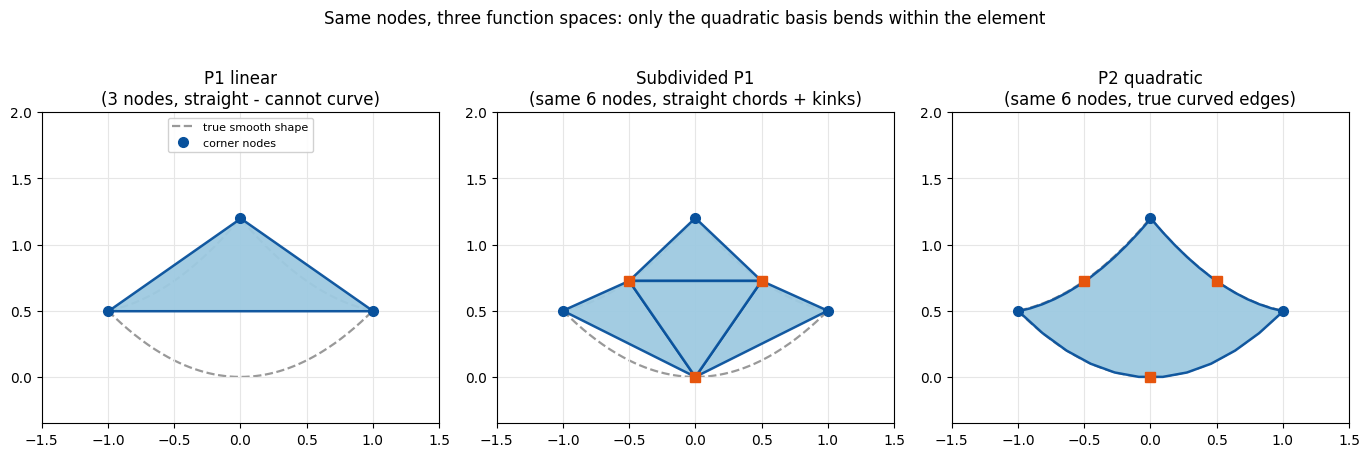

In [7]:
# One triangle under a known quadratic bending phi, rendered three ways on identical nodes.
def phi(P):
    P = np.atleast_2d(np.asarray(P, float))
    return np.column_stack([P[:, 0], P[:, 1] + 0.5 * P[:, 0] ** 2])

c     = np.array([[-1.0, 0.0], [1.0, 0.0], [0.0, 1.2]])                 # corners
mids  = np.array([0.5 * (c[0] + c[1]), 0.5 * (c[1] + c[2]), 0.5 * (c[2] + c[0])])
node6 = np.vstack([c, mids])                                           # [c0,c1,c2,m01,m12,m20]
U6, Uc = phi(node6), phi(c)

def ref_boundary(npts=160):                                            # true smooth deformed outline
    segs = [(c[0], c[1]), (c[1], c[2]), (c[2], c[0])]
    pts = [A * (1 - ts) + B * ts for A, B in segs for ts in [np.linspace(0, 1, npts)[:, None]]]
    return phi(np.vstack(pts))
truth = ref_boundary()

sub = np.array([[0, 3, 5], [3, 1, 4], [5, 4, 2], [3, 4, 5]])           # 4-way subdivision

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.7))
lims = ((-1.5, 1.5), (-0.35, 2.0))
titles = ["P1 linear\n(3 nodes, straight - cannot curve)",
          "Subdivided P1\n(same 6 nodes, straight chords + kinks)",
          "P2 quadratic\n(same 6 nodes, true curved edges)"]
for ax, title in zip(axes, titles):
    utils.setup_axes(ax, *lims, title=title)
    ax.plot(np.r_[truth[:, 0], truth[0, 0]], np.r_[truth[:, 1], truth[0, 1]],
            color="0.6", lw=1.6, ls="--", zorder=1, label="true smooth shape")

def add_poly(ax, polys):
    ax.add_collection(PolyCollection(polys, facecolors=utils.MESH_FACE,
                                     edgecolors=utils.MESH_EDGE, lw=1.8, alpha=0.95, zorder=2))

add_poly(axes[0], [Uc])                                                # P1: one flat triangle
add_poly(axes[1], [U6[f] for f in sub])                               # subdivided: straight chords
add_poly(axes[2], p2_curved_loops(U6, np.array([[0, 1, 2, 3, 4, 5]])))  # P2: curved

for ax, pts in zip(axes, [Uc, U6, U6]):
    ax.plot(pts[:3, 0], pts[:3, 1], "o", color="#08519c", ms=7, zorder=3, label="corner nodes")
    if len(pts) > 3:
        ax.plot(pts[3:, 0], pts[3:, 1], "s", color="#e6550d", ms=7, zorder=3, label="midpoint nodes")
axes[0].legend(loc="upper center", fontsize=8, framealpha=0.9)
fig.suptitle("Same nodes, three function spaces: only the quadratic basis bends within the element",
             fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig("media/12_p1_vs_subdivided_vs_p2.png", dpi=120)
plt.show()

### Static equilibrium: the unambiguous stiffness comparison

The animation above includes inertia, so at any instant both beams are still
swinging (and their different mass distributions put them slightly out of phase).
To compare *stiffness* cleanly we drop the inertia term and solve directly for the
gravity equilibrium &mdash; the shape each beam eventually settles into. Linear
triangles cannot bend within an element, so the P1 beam is artificially **stiff**
and deflects less than the more accurate P2 beam.

We reuse the *same* `FEMBeam` operators, but solve the static problem (no inertia)
by stepping each beam with a zero timestep contribution: we simply minimize
elastic + pin + gravity directly. Each beam writes its own explicit solve.

In [8]:
def static_equilibrium(beam, nodes):
    """Minimize elastic + pin + gravity potential (no inertia) for a FEMBeam's operators."""
    n, dim = nodes.shape
    def E(x):
        xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
        E_elastic = energies.macklin_mueller_neo_hookean_energy_x(xn, beam.J, beam.mu, beam.lam, beam.vol)
        E_pin     = 0.5 * (xc.T @ (beam.Q_pin @ xc))[0, 0] + (beam.b_pin.T @ xc)[0, 0]
        E_gravity = -(beam.f_g.T @ xc)[0, 0]
        return E_elastic + E_pin + E_gravity
    def G(x):
        xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
        g_elastic = energies.macklin_mueller_neo_hookean_gradient_x(xn, beam.J, beam.mu, beam.lam, beam.vol)
        g_pin     = beam.Q_pin @ xc + beam.b_pin
        g_gravity = -beam.f_g
        return g_elastic + g_pin + g_gravity
    def Hf(x):
        xn = x.reshape(-1, dim)
        H_elastic = energies.macklin_mueller_neo_hookean_hessian_x(xn, beam.J, beam.mu, beam.lam, beam.vol, psd=True)
        H_pin     = beam.Q_pin
        return H_elastic + H_pin
    x = newton_solver(nodes.reshape(-1, 1).copy(), E, G, Hf, max_iter=200, tolerance=1e-9)
    return x.reshape(n, dim)

eq1 = static_equilibrium(beam_p1, X)
eq2 = static_equilibrium(beam_p2, V2)
tip1, tip2 = eq1[:, 1].min(), eq2[:, 1].min()
print(f"P1 tip deflection: {tip1:.4f}")
print(f"P2 tip deflection: {tip2:.4f}   (P2 is {100*(tip2-tip1)/tip1:.1f}% more compliant)")

fig, anim = animate_p1_p2(
    [X, eq1], [V2, eq2], T, T2,
    lims=((-1.25, 1.45), (-2.1, 0.4)), fps=2,
    titles=(f"P1 equilibrium (tip {tip1:.3f})", f"P2 equilibrium (tip {tip2:.3f}, curved)"),
    suptitle="Static gravity equilibrium: linear elements are stiffer (deflect less)")
utils.show_video(fig, anim, "media/12_p1_vs_p2_static.mp4", fps=2)

P1 tip deflection: -1.5130
P2 tip deflection: -1.8640   (P2 is 23.2% more compliant)


## Part C &mdash; Convergence: P1 is first order, P2 is second order

The real payoff of quadratic elements is **accuracy per refinement**. We solve a
problem whose exact answer we know (the *method of manufactured solutions*) on a
sequence of meshes and watch the error shrink as the element size $h$ decreases.

We use **linear elasticity** (a linear PDE, so the rates are textbook-clean) on
the unit square with the smooth exact displacement
$u^*(x,y) = (s, s)$, $s = \sin(\pi a) \sin(\pi b)$, $a = x + 1/2$, $b = y + 1/2$ (which vanishes
on the boundary). We pick the body force $b = -\operatorname{div} \sigma(u^*)$ that makes $u^*$ the
exact solution, solve with both P1 and P2, and measure two error norms:

- **L2 (displacement):** $\lVert u_h - u^* \rVert$
- **H1 seminorm (strain / energy):** $\lVert \nabla u_h - \nabla u^* \rVert$

For a smooth solution and degree-$p$ elements the theory says:

| norm | rate | P1 ($p=1$) | P2 ($p=2$) |
|---|---|---|---|
| **H1 / strain** | $O(h^p)$   | $O(h)$  | $O(h^2)$ |
| **L2 / displacement** | $O(h^{p+1})$ | $O(h^2)$ | $O(h^3)$ |

So yes &mdash; exactly your intuition: in the energy/strain norm P1 is **first order**
and P2 is **second order**. Halving the element size cuts P1's strain error by ~2
but P2's by ~4, so P2 reaches a target accuracy on a far coarser mesh.

In [9]:
# ---- Method of manufactured solutions on the unit square [-1/2, 1/2]^2 ----
MU, LAM = simkit.ympr_to_lame(1.0, 0.3)

def u_star(P):                          # exact displacement; zero on the boundary
    a, b = P[..., 0] + 0.5, P[..., 1] + 0.5
    s = np.sin(np.pi * a) * np.sin(np.pi * b)
    return np.stack([s, s], axis=-1)

def grad_u_star(P):                     # rows = component i, cols = d/dX_j
    a, b = P[0] + 0.5, P[1] + 0.5
    sx = np.pi * np.cos(np.pi * a) * np.sin(np.pi * b)
    sy = np.pi * np.sin(np.pi * a) * np.cos(np.pi * b)
    return np.array([[sx, sy], [sx, sy]])

def body_force(P):                      # b = -mu*Lap(u) - (mu+lam)*grad(div u)
    a, b = P[0] + 0.5, P[1] + 0.5
    s = np.sin(np.pi * a) * np.sin(np.pi * b)
    c = np.cos(np.pi * a) * np.cos(np.pi * b)
    val = 2 * MU * np.pi**2 * s - (MU + LAM) * np.pi**2 * (c - s)
    return np.array([val, val])

def boundary_idx(V):
    return np.where((np.abs(V[:, 0] - 0.5) < 1e-9) | (np.abs(V[:, 0] + 0.5) < 1e-9) |
                    (np.abs(V[:, 1] - 0.5) < 1e-9) | (np.abs(V[:, 1] + 0.5) < 1e-9))[0]

def assemble_load(nodes, Telem, bary, weights, shape_at):
    """Consistent load vector f_i = integral N_i . b dV, by quadrature."""
    n, dim = nodes.shape
    t, nq, s = bary.shape
    f = np.zeros((n, dim))
    for e in range(t):
        Xc = nodes[Telem[e, :s]]                 # corners -> affine rest map
        for q in range(nq):
            L = bary[e, q]; xq = L @ Xc
            N = shape_at(L); bq = body_force(xq)
            for i, node in enumerate(Telem[e]):
                f[node] += weights[e, q] * N[i] * bq
    return f

def solve_linear_elastic(nodes, J, vol, f_load, bnd):
    """One linear solve (linear elasticity) with u=0 pinned on the boundary."""
    n, dim = nodes.shape
    mu = np.full((vol.shape[0], 1), MU); lam = np.full((vol.shape[0], 1), LAM)
    Q, b = simkit.dirichlet_penalty(bnd, nodes[bnd], n, 1e10)
    x0 = nodes.reshape(-1, 1)
    g = energies.linear_elasticity_gradient_x(nodes, J, mu, lam, vol) + Q @ x0 + b - f_load.reshape(-1, 1)
    H = energies.linear_elasticity_hessian_x(nodes, J, mu, lam, vol, psd=True) + Q
    dx = sp.sparse.linalg.spsolve(H.tocsc(), -g).reshape(-1, 1)
    return (x0 + dx).reshape(n, dim)

def error_norms(nodes, Telem, x, bary, weights, F, shape_at):
    """L2 displacement error and H1 (strain) seminorm error vs the exact field."""
    n, dim = nodes.shape
    t, nq, s = bary.shape
    l2 = h1 = 0.0
    for e in range(t):
        Xc = nodes[Telem[e, :s]]
        uel = x[Telem[e]] - nodes[Telem[e]]      # nodal displacements
        for q in range(nq):
            L = bary[e, q]; wq = weights[e, q]; xq = L @ Xc
            uh = shape_at(L) @ uel               # interpolated FE displacement
            l2 += wq * np.sum((uh - u_star(xq))**2)
            h1 += wq * np.sum((F[e, q] - np.eye(dim) - grad_u_star(xq))**2)  # grad u_h = F - I
    return np.sqrt(l2), np.sqrt(h1)

P1_SHAPE = lambda L: L                                    # linear hats = barycentric coords
P2_SHAPE = lambda L: simkit.p2_shape_functions(L, 3)[0]   # quadratic shape functions

### Refinement sweep

We loop over a sequence of mesh resolutions, solving the manufactured problem with
both P1 and P2 on each mesh and recording both error norms. The loop is explicit:
each iteration builds its own meshes, operators, loads and errors inline.

P1  H1 (strain) order = 0.99   (theory 1)
P2  H1 (strain) order = 1.98   (theory 2)
P1  L2 (displ.) order = 1.98   (theory 2)
P2  L2 (displ.) order = 2.97   (theory 3)


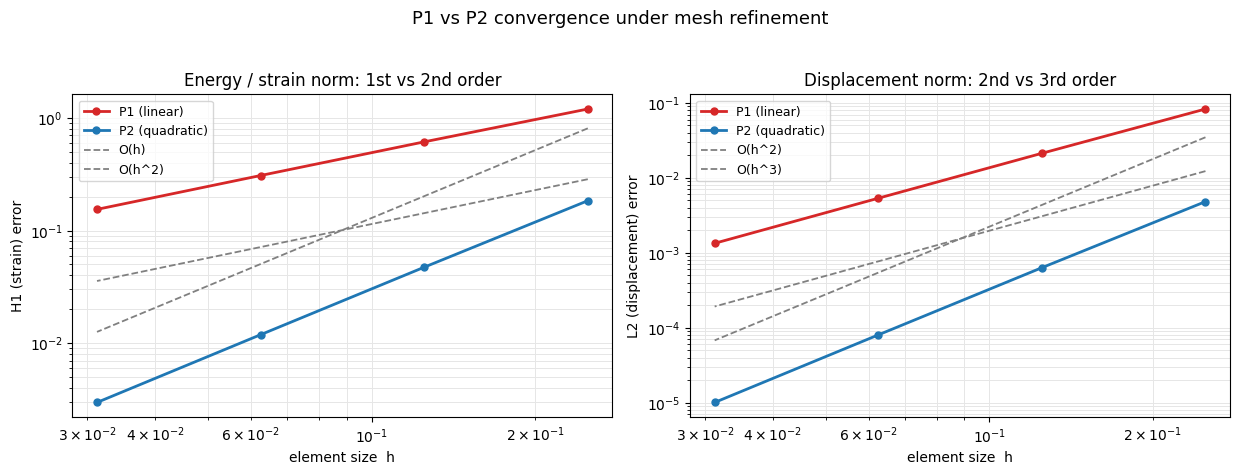

In [10]:
resolutions = [4, 8, 16, 32]
hs = []
err = {"P1 L2": [], "P1 H1": [], "P2 L2": [], "P2 H1": []}
for nn in resolutions:
    X, T = utils.triangulated_grid(nx=nn + 1, ny=nn + 1, width=1.0, height=1.0)
    hs.append(1.0 / nn)
    bq, wq = simkit.gauss_legendre_quadrature(X, T, 4)    # accurate load + error quadrature

    # --- P1 ---
    J1, v1 = simkit.deformation_jacobian(X, T), simkit.volume(X, T)
    f1 = assemble_load(X, T, bq, wq, P1_SHAPE)
    x1 = solve_linear_elastic(X, J1, v1, f1, boundary_idx(X))
    F1 = np.repeat(simkit.deformation_gradient(X, T, x1)[:, None], bq.shape[1], axis=1)
    l2, h1 = error_norms(X, T, x1, bq, wq, F1, P1_SHAPE)
    err["P1 L2"].append(l2); err["P1 H1"].append(h1)

    # --- P2 ---
    V2, T2 = simkit.linear_to_quadratic_elements(X, T)
    b2, w2 = simkit.gauss_legendre_quadrature(X, T, 2)    # order 2 for the elastic stiffness
    J2, v2 = simkit.deformation_jacobian_p2(V2, T2, b2, w2), w2.reshape(-1, 1)
    f2 = assemble_load(V2, T2, bq, wq, P2_SHAPE)
    x2 = solve_linear_elastic(V2, J2, v2, f2, boundary_idx(V2))
    F2 = simkit.deformation_gradient_p2(V2, T2, bq, x2)
    l2, h1 = error_norms(V2, T2, x2, bq, wq, F2, P2_SHAPE)
    err["P2 L2"].append(l2); err["P2 H1"].append(h1)

hs = np.array(hs)
slope = lambda e: np.polyfit(np.log(hs), np.log(e), 1)[0]
print(f"P1  H1 (strain) order = {slope(err['P1 H1']):.2f}   (theory 1)")
print(f"P2  H1 (strain) order = {slope(err['P2 H1']):.2f}   (theory 2)")
print(f"P1  L2 (displ.) order = {slope(err['P1 L2']):.2f}   (theory 2)")
print(f"P2  L2 (displ.) order = {slope(err['P2 L2']):.2f}   (theory 3)")

colors = {"P1 (linear)": "#d62728", "P2 (quadratic)": "#1f77b4"}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
utils.loglog_plot(hs, {"P1 (linear)": err["P1 H1"], "P2 (quadratic)": err["P2 H1"]},
                  xlabel="element size  h", ylabel="H1 (strain) error", colors=colors,
                  ref_slopes={"O(h)": 1, "O(h^2)": 2},
                  title="Energy / strain norm: 1st vs 2nd order", ax=axes[0])
utils.loglog_plot(hs, {"P1 (linear)": err["P1 L2"], "P2 (quadratic)": err["P2 L2"]},
                  xlabel="element size  h", ylabel="L2 (displacement) error", colors=colors,
                  ref_slopes={"O(h^2)": 2, "O(h^3)": 3},
                  title="Displacement norm: 2nd vs 3rd order", ax=axes[1])
fig.suptitle("P1 vs P2 convergence under mesh refinement", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig("media/12_convergence.png", dpi=120)
plt.show()

### Takeaways

- At **static equilibrium** the **P1** beam is artificially **stiff** (linear
  elements cannot bend within an element) and deflects less, while **P2** sags
  further and more smoothly. The dynamic animation adds inertia on top, so both
  beams swing (and, having different mass distributions, do so slightly out of
  phase).
- **It is not a subdivided mesh.** P2 and a 4-way subdivision share the *same 6
  nodes*, but only the quadratic basis bends *within* an element &mdash; its edges are
  genuine parabolas (Part B), and it reproduces quadratic fields exactly while no
  linear scheme on those nodes can.
- **Convergence (Part C):** P1 is **first order** and P2 is **second order** in
  the energy/strain norm ($O(h)$ vs $O(h^2)$), and one order higher in the L2
  displacement norm &mdash; so P2 reaches a target accuracy on a much coarser mesh.
- The elastic energy, gradient and Hessian code was **reused unchanged**
  throughout; P2 only changed $J$ (now mapping to per-cubature $F$), the
  integration weights, and the mass/gravity assembly.